Feature columns (order): ['Streamflow', 'E Dezdam', 'E Bakhtiari', 'P Kamandan', 'P Bakhtiari', 'P Talezang', 'P Vanayi', 'P Chamzaman', 'P Daretakht', 'P Chamchit', 'P Sezar', 'P Keshvar', 'P Broujerd', 'P Kazemabad', 'P Rahimabad', 'P Zardefahre', 'P Sibak', 'P Sekane', 'BO tmean', 'nm', 'Humidity', 'sunshine', 'Alitmax', 'Rain', 'nm.1', 'Humidity.1', 'sunshine.1', 'BA-Nam', 'dam_min_630', 'DEZ-Nam', 'dam_min_630.1']
Target column: Streamflow (used at t as label; its lags are in inputs)


<timed exec>:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_30 (GRU)                    │ (None, 18, 256)        │       221,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 18, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_31 (GRU)                    │ (None, 128)            │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 370,305 (1.41 MB)

 Trainable params: 370,305 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - loss: 1.3985 - val_loss: 0.6492
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5866 - val_loss: 0.3769
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4350 - val_loss: 0.3267
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3469 - val_loss: 0.3375
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3121 - val_loss: 0.2470
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2574 - val_loss: 0.2326
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2430 - val_loss: 0.1952
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2192 - val_loss: 0.2087
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2152 - val_loss: 0.1456
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1956 - val_loss: 0.1742
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1902 - val_loss: 0.1240
Epoch 12/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1794 - val

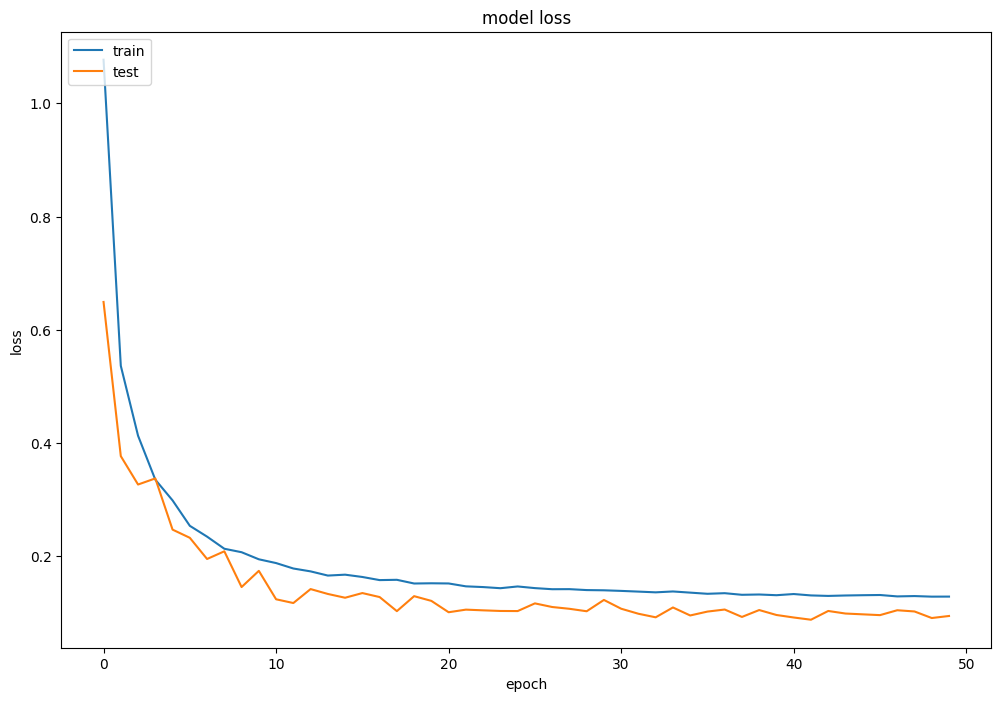

CPU times: user 41.3 s, sys: 1.42 s, total: 42.7 s
Wall time: 42.1 s


In [111]:
%%time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as sts
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dropout,LSTM,Dense,GRU,Conv1D,MaxPooling1D,Flatten,LeakyReLU
from keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
from tensorflow.keras.regularizers import l1_l2, OrthogonalRegularizer,l1,l2
path='/content/26.csv'
dataset=pd.read_csv(path,index_col='Date')
dataset
cols = pd.read_csv(path, index_col='Date').columns.tolist()
print("Feature columns (order):", cols)
print("Target column:", cols[0], "(used at t as label; its lags are in inputs)")

#==============Check and Fill the Missvalues===============

#dataset.isnull().sum()#
dataset=dataset.fillna(method='bfill')
#dataset.isnull().sum()#

#=============Plot the Multivariate Timeseries=============

#dataset.hist(figsize=(50,20))
#dataset.plot(subplots=True,figsize=(30,30))

#=============Choose the Optimal Lag Observation===========

dataset=pd.DataFrame(dataset)
sts.adfuller(dataset.Streamflow)
#plot_acf(dataset.Streamflow, lags=50,zero=False)#
#plt.show()
lag=18

#==============Split the Data ====================

TRAIN_SPLIT=int(len(dataset)*0.8)
TRAIN_SPLIT
dataset=np.array(dataset)

#================to Supervised=============================

def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
    data = []
    labels = []
    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size
    for i in range(start_index, end_index):
        indices = range(i-history_size, i, step)
        data.append(dataset[indices])
        if single_step:
            labels.append(target[i+target_size])
        else:
            labels.append(target[i:i+target_size])
    return np.array(data), np.array(labels)

past_history = lag
STEP = 1
n_step=1

x_train_multi, y_train_multi= multivariate_data(dataset, dataset[:,0], 0,
                                                   TRAIN_SPLIT, past_history,
                                                   n_step, STEP,
                                                   single_step=False)
x_test_multi, y_test_multi = multivariate_data(dataset, dataset[:, 0],
                                               TRAIN_SPLIT, None, past_history,
                                               n_step, STEP,
                                               single_step=False)
#======================= Scale data  ===================#
from sklearn.preprocessing import StandardScaler
import numpy as np

n_features = x_train_multi.shape[2]

# y: StandardScaler
scaler_y = StandardScaler()
y_train_multi = scaler_y.fit_transform(y_train_multi.reshape(-1,1)).reshape(y_train_multi.shape)
y_test_multi  = scaler_y.transform(y_test_multi.reshape(-1,1)).reshape(y_test_multi.shape)

# X: StandardScaler per feature
x_scalers = {}
for f in range(n_features):
    sc = StandardScaler()
    tr = x_train_multi[:, :, f].reshape(-1,1)
    te = x_test_multi[:,  :, f].reshape(-1,1)
    sc.fit(tr)
    x_train_multi[:, :, f] = sc.transform(tr).reshape(x_train_multi.shape[0], x_train_multi.shape[1])
    x_test_multi[:,  :, f] = sc.transform(te).reshape(x_test_multi.shape[0], x_test_multi.shape[1])
    x_scalers[f] = sc

#===================== GRU ====================
#,kernel_regularizer=l1_l2(l1=0.001, l2=0.001)
#GRU_model.add(GRU(128,activation='elu',return_sequences=True))
#GRU_model.add(Dropout(0.2))


GRU_model = Sequential()
GRU_model.add(GRU(256,input_shape=x_train_multi.shape[-2:],activation='elu',return_sequences=True,kernel_regularizer=l1_l2(l1=0.001, l2=0.001)))
GRU_model.add(Dropout(0.1))
GRU_model.add(GRU(128,activation='elu'))
GRU_model.add(Dense(n_step,activation='selu'))
GRU_model.compile(optimizer='rmsprop', loss='mae')
GRU_model.summary()
history_GRU=GRU_model.fit(x_train_multi,y_train_multi,
                                            epochs=50,batch_size=128,shuffle=False,validation_data=(x_test_multi,y_test_multi))

#========== Learning Curve ==================#
plt.figure(figsize=(12,8))
plt.plot(history_GRU.history['loss'])
plt.plot(history_GRU.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()




=== Metrics (original scale) ===
            NSE        R2        RMSE        MAE       KGE
Train  0.802981  0.809975  128.709357  27.439603  0.791897
Test   0.830461  0.837939   46.660383  20.444992  0.822559


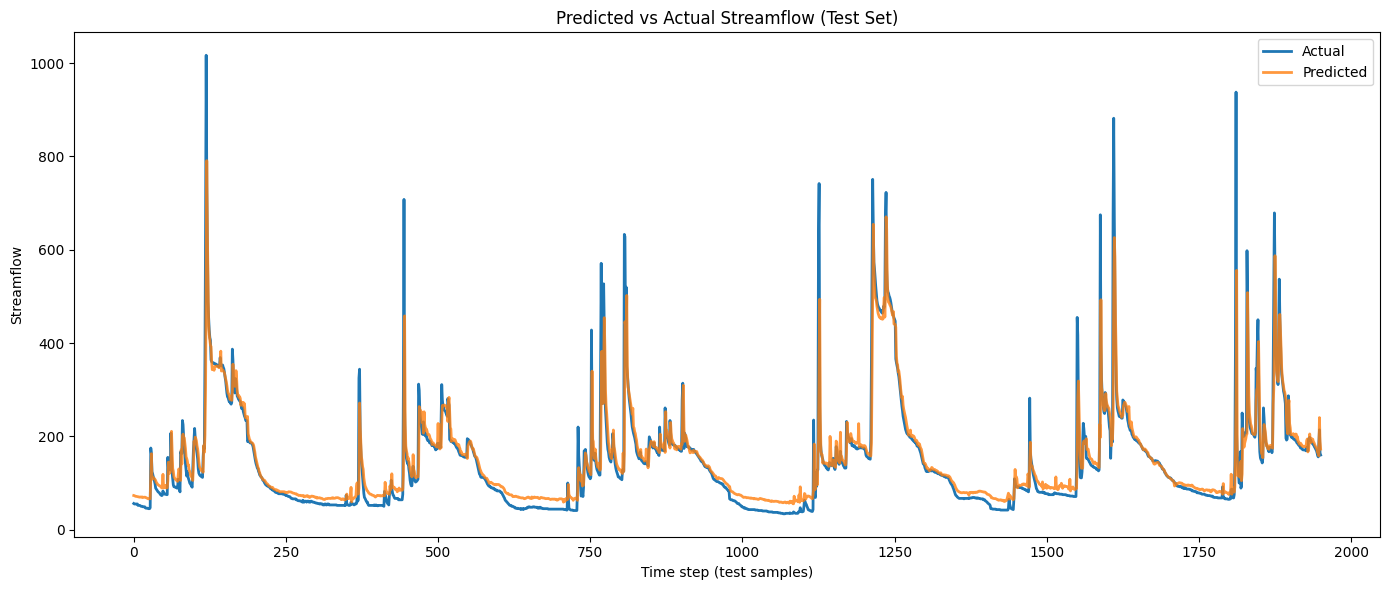

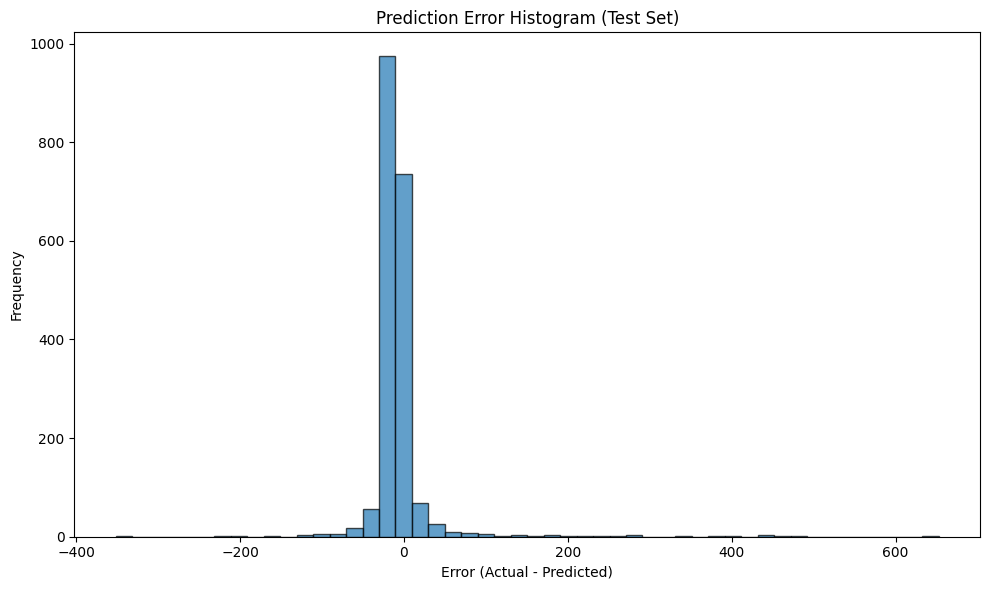

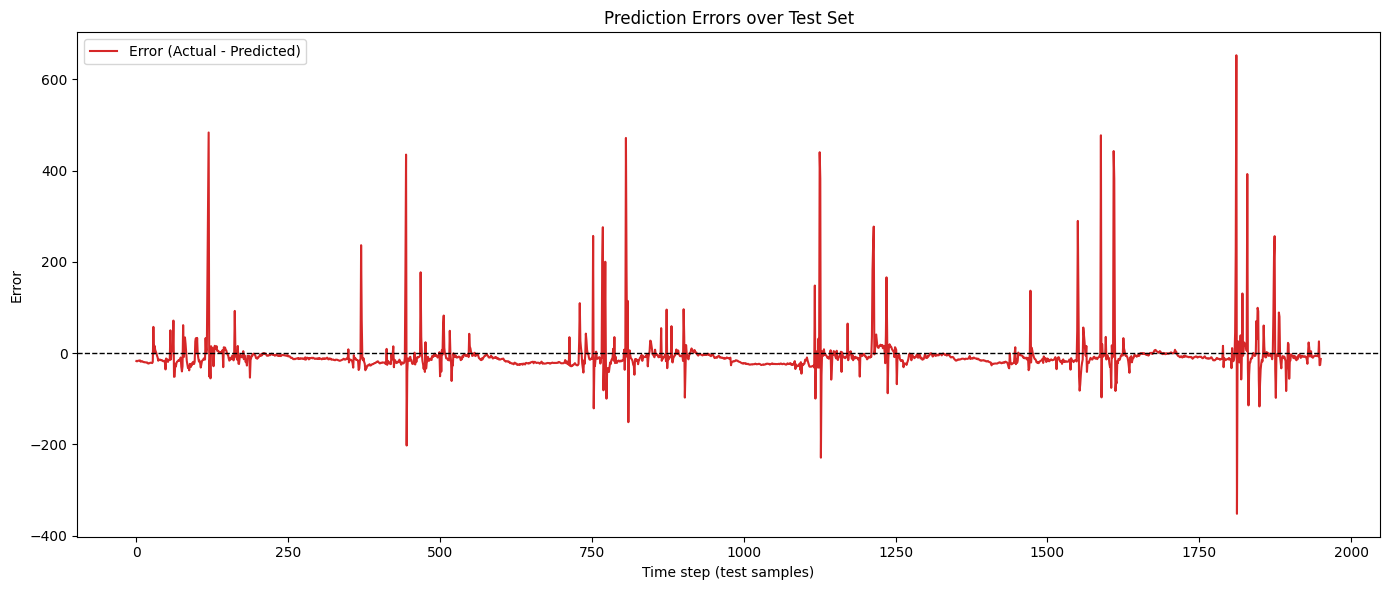

In [112]:
# ===== Metrics on ORIGINAL scale (after your learning-curve plot) =====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _inverse_targets(y_scaled, scaler_y):
    """Undo y scaling (no log). If scaler_y is None, return as-is."""
    if scaler_y is None:
        return y_scaled.copy()
    y_inv = scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).reshape(y_scaled.shape)
    return y_inv

def _align_finite(obs, sim):
    """Drop any NaN/Inf pairs to avoid metric/hist errors."""
    obs = np.asarray(obs).ravel().astype(float)
    sim = np.asarray(sim).ravel().astype(float)
    m = np.isfinite(obs) & np.isfinite(sim)
    return obs[m], sim[m]

def nse(obs, sim):
    """Nash–Sutcliffe Efficiency on original scale."""
    obs, sim = _align_finite(obs, sim)
    if obs.size == 0:
        return np.nan
    denom = np.sum((obs - np.mean(obs))**2)
    if denom == 0:
        return np.nan
    return 1.0 - np.sum((obs - sim)**2) / denom

def r2_custom(obs, sim):
    """R² = squared Pearson correlation."""
    obs, sim = _align_finite(obs, sim)
    if obs.size == 0:
        return np.nan
    o_bar = np.mean(obs)
    s_bar = np.mean(sim)
    num = np.sum((obs - o_bar) * (sim - s_bar))**2
    denom = np.sum((obs - o_bar)**2) * np.sum((sim - s_bar)**2)
    if denom == 0:
        return np.nan
    return num / denom

def rmse(obs, sim):
    obs, sim = _align_finite(obs, sim)
    if obs.size == 0:
        return np.nan
    return np.sqrt(np.mean((obs - sim)**2))

def mae(obs, sim):
    obs, sim = _align_finite(obs, sim)
    if obs.size == 0:
        return np.nan
    return np.mean(np.abs(obs - sim))

# ---- ADDED: Kling-Gupta Efficiency (revised 2012) ----
def kge(obs, sim):
    """
    Kling-Gupta Efficiency (revised 2012, 'KGE\'').
    KGE = 1 - sqrt((r - 1)^2 + (alpha - 1)^2 + (beta - 1)^2)
      r     = Pearson correlation(obs, sim)
      alpha = std(sim) / std(obs)
      beta  = mean(sim) / mean(obs)
    Returns NaN if undefined (e.g., zero std or zero mean in denom).
    """
    obs, sim = _align_finite(obs, sim)
    if obs.size == 0:
        return np.nan

    mu_o = np.mean(obs)
    mu_s = np.mean(sim)
    # use sample std (ddof=1) to match common hydro practice; fall back to population if needed
    std_o = np.std(obs, ddof=1)
    std_s = np.std(sim, ddof=1)

    # correlation
    if obs.size < 2:
        return np.nan
    r = np.corrcoef(obs, sim)[0, 1]

    # guard against zero divisions / invalid r
    if not np.isfinite(r) or std_o == 0 or mu_o == 0:
        return np.nan

    alpha = std_s / std_o
    beta  = mu_s / mu_o

    return 1.0 - np.sqrt((r - 1.0)**2 + (alpha - 1.0)**2 + (beta - 1.0)**2)
# ---- END ADDED ----

# Predictions (on scaled space)
y_pred_train_scaled = GRU_model.predict(x_train_multi, verbose=0)
y_pred_test_scaled  = GRU_model.predict(x_test_multi,  verbose=0)

# Back to original space (NO log; just inverse of scaler_y if present)
y_train_orig = _inverse_targets(y_train_multi, scaler_y)
y_test_orig  = _inverse_targets(y_test_multi,  scaler_y)
y_pred_train_orig = _inverse_targets(y_pred_train_scaled, scaler_y)
y_pred_test_orig  = _inverse_targets(y_pred_test_scaled,  scaler_y)

# Optional: clip negatives (e.g., flow can't be < 0)
y_train_orig = np.clip(y_train_orig, 0, None)
y_test_orig  = np.clip(y_test_orig, 0, None)
y_pred_train_orig = np.clip(y_pred_train_orig, 0, None)
y_pred_test_orig  = np.clip(y_pred_test_orig, 0, None)

# Compute metrics
metrics = {
    'NSE': [
        nse(y_train_orig, y_pred_train_orig),
        nse(y_test_orig,  y_pred_test_orig)
    ],
    'R2': [
        r2_custom(y_train_orig, y_pred_train_orig),
        r2_custom(y_test_orig,  y_pred_test_orig)
    ],
    'RMSE': [
        rmse(y_train_orig, y_pred_train_orig),
        rmse(y_test_orig,  y_pred_test_orig)
    ],
    'MAE': [
        mae(y_train_orig, y_pred_train_orig),
        mae(y_test_orig,  y_pred_test_orig)
    ],
    # ---- ADDED: KGE on original scale ----
    'KGE': [
        kge(y_train_orig, y_pred_train_orig),
        kge(y_test_orig,  y_pred_test_orig)
    ],
    # --------------------------------------
}
metrics_df = pd.DataFrame(metrics, index=['Train', 'Test'])
print("\n=== Metrics (original scale) ===")
print(metrics_df)

# ===== Line chart: Predicted vs Actual (Test set) =====
plt.figure(figsize=(14,6))
plt.plot(y_test_orig, label='Actual', linewidth=2)
plt.plot(y_pred_test_orig, label='Predicted', linewidth=2, alpha=0.8)
plt.title("Predicted vs Actual Streamflow (Test Set)")
plt.xlabel("Time step (test samples)")
plt.ylabel("Streamflow")
plt.legend()
plt.tight_layout()
plt.show()

# ===== Prediction Error Histogram (Test set) =====
errors = (y_test_orig - y_pred_test_orig).ravel()
errors = errors[np.isfinite(errors)]  # avoid non-finite crash

plt.figure(figsize=(10,6))
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.title("Prediction Error Histogram (Test Set)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ===== Error over Test Set (time series) =====
plt.figure(figsize=(14,6))
plt.plot(errors, label="Error (Actual - Predicted)", color="tab:red", linewidth=1.5)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Prediction Errors over Test Set")
plt.xlabel("Time step (test samples)")
plt.ylabel("Error")
plt.legend()
plt.tight_layout()
plt.show()



=== Metrics (original scale) ===
            NSE        R2        RMSE        MAE       KGE
Train  0.802981  0.809975  128.709357  27.439603  0.791897
Test   0.830461  0.837939   46.660383  20.444992  0.822559


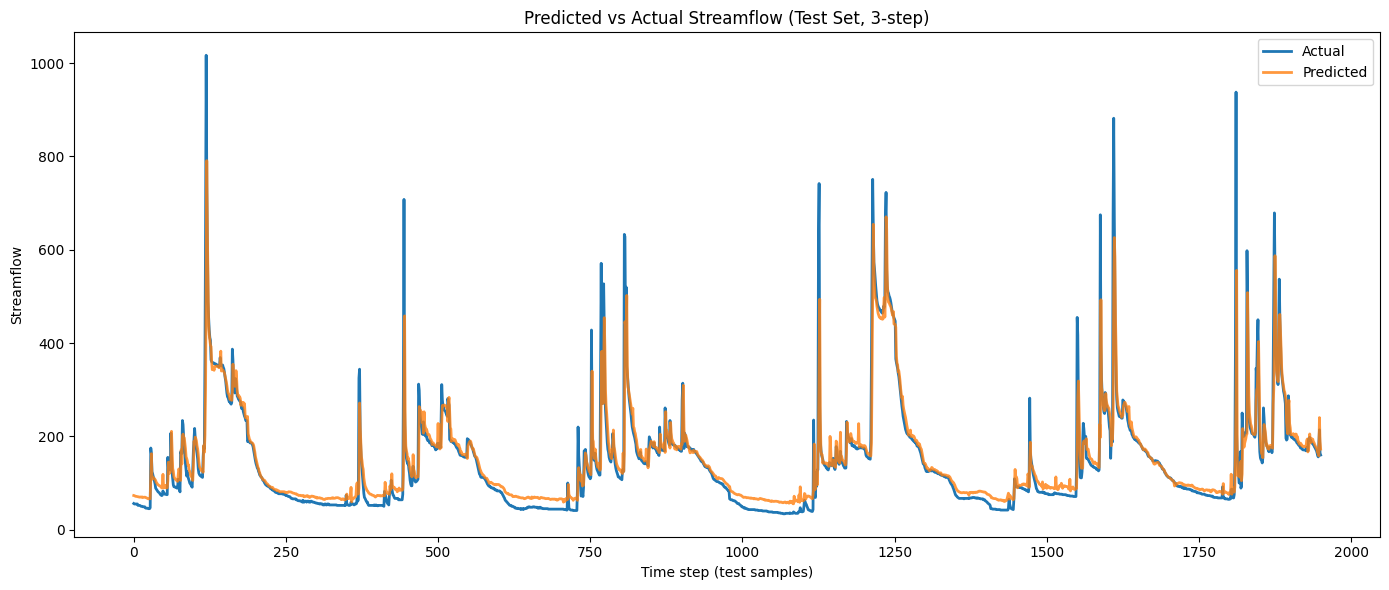

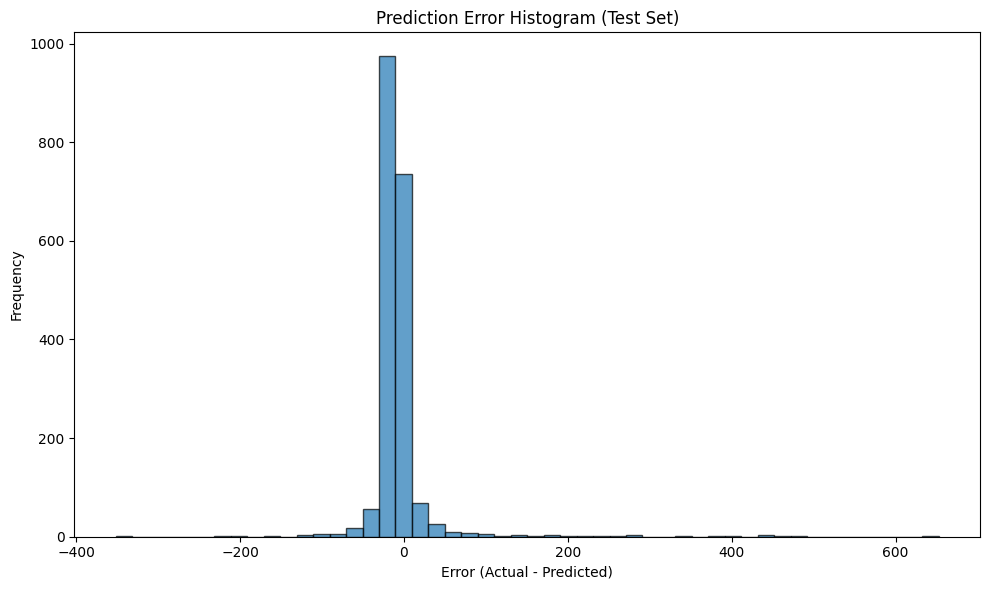

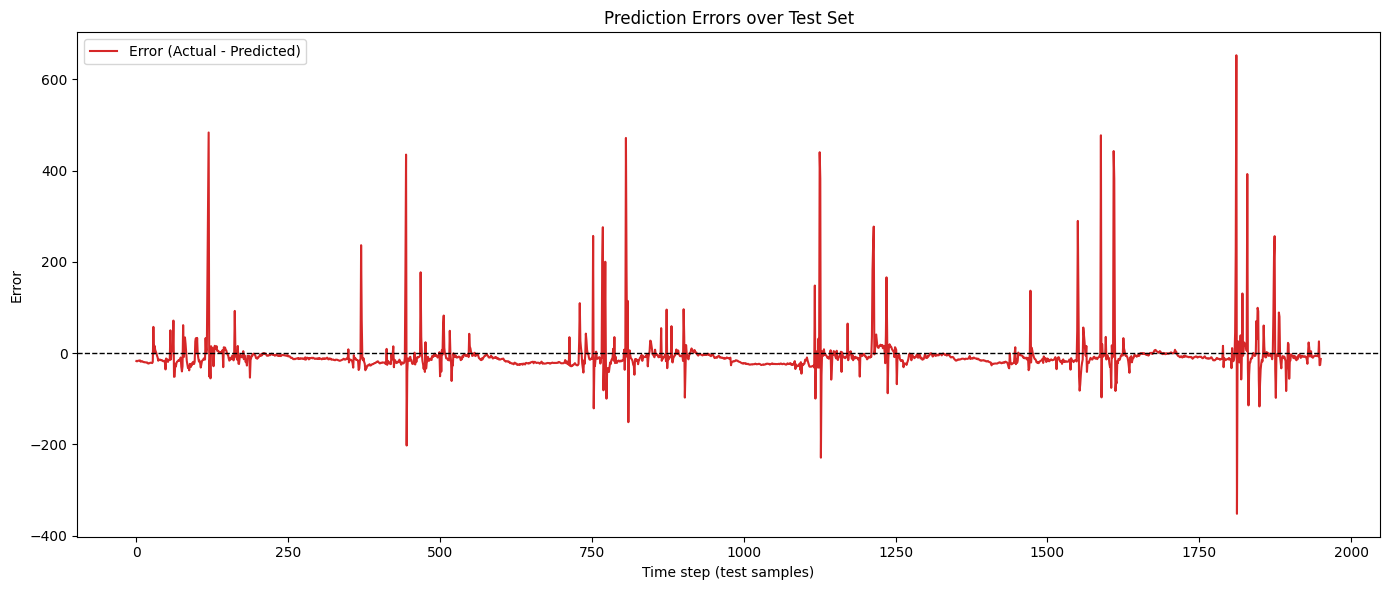

In [113]:
# ========== Metrics on ORIGINAL scale ================ # N-STEP
# ===================================================== #
def _inverse_targets(y_scaled, scaler_y):
    if scaler_y is None:
        return y_scaled.copy()
    y_inv = scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).reshape(y_scaled.shape)
    return y_inv

def _align_finite(obs, sim):
    obs = np.asarray(obs).ravel().astype(float)
    sim = np.asarray(sim).ravel().astype(float)
    m = np.isfinite(obs) & np.isfinite(sim)
    return obs[m], sim[m]

def nse(obs, sim):
    obs, sim = _align_finite(obs, sim)
    if obs.size == 0: return np.nan
    denom = np.sum((obs - np.mean(obs))**2)
    if denom == 0: return np.nan
    return 1.0 - np.sum((obs - sim)**2) / denom

def r2_custom(obs, sim):
    obs, sim = _align_finite(obs, sim)
    if obs.size == 0: return np.nan
    o_bar, s_bar = np.mean(obs), np.mean(sim)
    num = np.sum((obs - o_bar) * (sim - s_bar))**2
    denom = np.sum((obs - o_bar)**2) * np.sum((sim - s_bar)**2)
    if denom == 0: return np.nan
    return num / denom

def rmse(obs, sim):
    obs, sim = _align_finite(obs, sim)
    if obs.size == 0: return np.nan
    return np.sqrt(np.mean((obs - sim)**2))

def mae(obs, sim):
    obs, sim = _align_finite(obs, sim)
    if obs.size == 0: return np.nan
    return np.mean(np.abs(obs - sim))

# ---- ADDED: Kling-Gupta Efficiency (revised 2012) ----
def kge(obs, sim):
    """
    Kling-Gupta Efficiency (revised 2012).
    KGE = 1 - sqrt((r - 1)^2 + (alpha - 1)^2 + (beta - 1)^2)
      r     = Pearson correlation(obs, sim)
      alpha = std(sim) / std(obs)
      beta  = mean(sim) / mean(obs)
    """
    obs, sim = _align_finite(obs, sim)
    if obs.size == 0:
        return np.nan
    if obs.size < 2:
        return np.nan

    # Pearson correlation
    r = np.corrcoef(obs, sim)[0, 1]

    mu_o = np.mean(obs)
    mu_s = np.mean(sim)
    std_o = np.std(obs, ddof=1)
    std_s = np.std(sim, ddof=1)

    if not np.isfinite(r) or std_o == 0 or mu_o == 0:
        return np.nan

    alpha = std_s / std_o
    beta  = mu_s / mu_o

    return 1.0 - np.sqrt((r - 1.0)**2 + (alpha - 1.0)**2 + (beta - 1.0)**2)
# ---- END ADDED ----

# Predictions
y_pred_train_scaled = GRU_model.predict(x_train_multi, verbose=0)
y_pred_test_scaled  = GRU_model.predict(x_test_multi,  verbose=0)

# Back to original space
y_train_orig = _inverse_targets(y_train_multi, scaler_y)
y_test_orig  = _inverse_targets(y_test_multi,  scaler_y)
y_pred_train_orig = _inverse_targets(y_pred_train_scaled, scaler_y)
y_pred_test_orig  = _inverse_targets(y_pred_test_scaled,  scaler_y)

# Clip negatives if needed
y_train_orig = np.clip(y_train_orig, 0, None)
y_test_orig  = np.clip(y_test_orig, 0, None)
y_pred_train_orig = np.clip(y_pred_train_orig, 0, None)
y_pred_test_orig  = np.clip(y_pred_test_orig, 0, None)

# Metrics
metrics = {
    'NSE': [nse(y_train_orig, y_pred_train_orig),
            nse(y_test_orig,  y_pred_test_orig)],
    'R2':  [r2_custom(y_train_orig, y_pred_train_orig),
            r2_custom(y_test_orig,  y_pred_test_orig)],
    'RMSE':[rmse(y_train_orig, y_pred_train_orig),
            rmse(y_test_orig,  y_pred_test_orig)],
    'MAE': [mae(y_train_orig, y_pred_train_orig),
            mae(y_test_orig,  y_pred_test_orig)],
    # ---- ADDED: KGE ----
    'KGE': [kge(y_train_orig, y_pred_train_orig),
            kge(y_test_orig,  y_pred_test_orig)]
    # --------------------
}
metrics_df = pd.DataFrame(metrics, index=['Train', 'Test'])
print("\n=== Metrics (original scale) ===")
print(metrics_df)

# Plot: Predicted vs Actual (flattened sequences)
plt.figure(figsize=(14,6))
plt.plot(y_test_orig.ravel(), label='Actual', linewidth=2)
plt.plot(y_pred_test_orig.ravel(), label='Predicted', linewidth=2, alpha=0.8)
plt.title("Predicted vs Actual Streamflow (Test Set, 3-step)")
plt.xlabel("Time step (test samples)")
plt.ylabel("Streamflow")
plt.legend()
plt.tight_layout()
plt.show()

# Error histogram
errors = (y_test_orig - y_pred_test_orig).ravel()
errors = errors[np.isfinite(errors)]
plt.figure(figsize=(10,6))
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.title("Prediction Error Histogram (Test Set)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Error over time
plt.figure(figsize=(14,6))
plt.plot(errors, label="Error (Actual - Predicted)", color="tab:red", linewidth=1.5)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Prediction Errors over Test Set")
plt.xlabel("Time step (test samples)")
plt.ylabel("Error")
plt.legend()
plt.tight_layout()
plt.show()


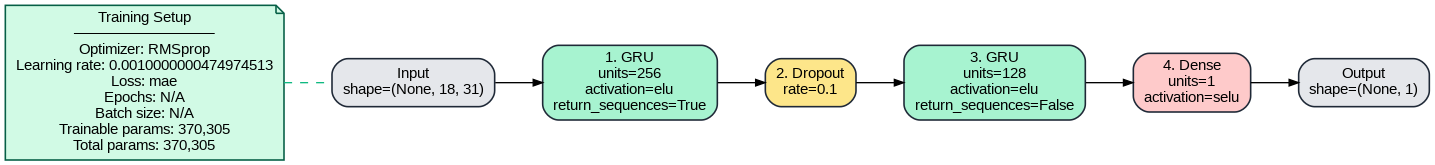

kernel                                   (31, 768)  ->  23,808
recurrent_kernel                         (256, 768)  ->  196,608
bias                                     (2, 768)  ->  1,536
kernel                                   (256, 384)  ->  98,304
recurrent_kernel                         (128, 384)  ->  49,152
bias                                     (2, 384)  ->  768
kernel                                   (128, 1)  ->  128
bias                                     (1,)  ->  1
TOTAL: 370305


In [114]:
# ================= FLOWCHART OF MODEL ARCHITECTURE (Colab-ready) =================
# (1) Install deps (safe to run multiple times)
# If you're not on Colab, you can skip these two lines.
!apt-get -qq install graphviz > /dev/null
!pip -q install graphviz

# (2) Imports
from graphviz import Digraph
from IPython.display import Image, display
import tensorflow as tf
import numpy as np

def _safe_shape(shape_like):
    try:
        return tuple(int(x) if x is not None else None for x in tuple(shape_like))
    except Exception:
        return str(shape_like)

def draw_model_flowchart(model,
                         history=None,
                         batch_size=None,
                         filename='model_flowchart'):
    """
    Renders a flowchart of a Keras model with a side 'Training Setup' card.
    - Boxes: layers with units/activation/return_sequences/dropout/conv/pool/dense/flatten.
    - Side card: optimizer, lr, loss, epochs, batch size, trainable/total params.
    Returns: path to PNG file.
    """
    g = Digraph('G', format='png')
    # Layout + default node styling
    g.attr(rankdir='LR', splines='ortho', concentrate='true', bgcolor='white')
    g.attr('node', shape='box', style='rounded,filled', color='#1f2937',
           fontname='Helvetica', fontsize='11', penwidth='1.2')

    # Helper: alternated fill colors per layer type
    def layer_fill(class_name):
        return {
            'SimpleRNN':   '#bfdbfe',  # blue-200
            'LSTM':        '#c7d2fe',  # indigo-200
            'GRU':         '#a7f3d0',  # emerald-200
            'Dropout':     '#fde68a',  # amber-200
            'Dense':       '#fecaca',  # red-200
            'Conv1D':      '#e9d5ff',  # violet-200
            'MaxPooling1D':'#ddd6fe',  # violet-200-ish
            'Flatten':     '#ddd6fe',
            'InputLayer':  '#e5e7eb',
        }.get(class_name, '#e5e7eb')  # gray-200 default

    # Input box
    try:
        in_shape = _safe_shape(model.input_shape)
    except Exception:
        # try to infer from first layer if possible
        try:
            first = model.layers[0]
            in_shape = _safe_shape(getattr(first, 'input_shape', 'unknown'))
        except Exception:
            in_shape = 'unknown'
    g.node('input', f'Input\nshape={in_shape}', fillcolor='#e5e7eb')

    # Layer boxes
    prev = 'input'
    for i, layer in enumerate(model.layers, start=1):
        cfg = layer.get_config()
        cls = layer.__class__.__name__

        if cls in ('SimpleRNN', 'LSTM', 'GRU'):
            label = (f'{cls}\\n'
                     f'units={cfg.get("units")}\\n'
                     f'activation={cfg.get("activation")}\\n'
                     f'return_sequences={cfg.get("return_sequences")}')
        elif cls == 'Dense':
            label = (f'Dense\\n'
                     f'units={cfg.get("units")}\\n'
                     f'activation={cfg.get("activation")}')
        elif cls == 'Dropout':
            label = f'Dropout\\nrate={cfg.get("rate")}'
        elif cls == 'Conv1D':
            label = (f'Conv1D\\n'
                     f'filters={cfg.get("filters")}\\n'
                     f'kernel_size={cfg.get("kernel_size")}\\n'
                     f'activation={cfg.get("activation")}')
        elif cls == 'MaxPooling1D':
            label = f'MaxPooling1D\\npool_size={cfg.get("pool_size")}'
        elif cls == 'Flatten':
            label = 'Flatten'
        elif cls == 'InputLayer':
            # already reflected by the Input box; still show for completeness
            label = f'InputLayer\\nshape={cfg.get("batch_input_shape")}'
        else:
            # Generic fallback with class name
            label = cls

        node_id = f'L{i}'
        g.node(node_id, f'{i}. {label}', fillcolor=layer_fill(cls))
        g.edge(prev, node_id, arrowsize='0.7')
        prev = node_id

    # Output box
    try:
        out_shape = _safe_shape(model.output_shape)
    except Exception:
        out_shape = 'unknown'
    g.node('output', f'Output\nshape={out_shape}', fillcolor='#e5e7eb')
    g.edge(prev, 'output', arrowsize='0.7')

    # Side "Training Setup" card
    opt = getattr(model, 'optimizer', None)
    if opt is not None:
        opt_name = opt.__class__.__name__
        # Try to resolve learning rate to a float if constant; otherwise show type
        try:
            lr_val = tf.keras.backend.get_value(opt.learning_rate)
            lr = float(lr_val) if np.ndim(lr_val) == 0 else 'schedule'
        except Exception:
            lr = 'schedule'
    else:
        opt_name, lr = 'N/A', 'N/A'

    # Loss name: could be string, function, or Loss instance
    loss_attr = getattr(model, 'loss', 'N/A')
    try:
        if isinstance(loss_attr, (str, bytes)):
            loss_name = loss_attr
        elif hasattr(loss_attr, '__name__'):
            loss_name = loss_attr.__name__
        else:
            loss_name = loss_attr.__class__.__name__
    except Exception:
        loss_name = 'N/A'

    epochs = len(getattr(history, 'epoch', [])) if history is not None else 'N/A'
    batch = batch_size if batch_size is not None else 'N/A'

    trainable = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    non_trainable = int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))
    total_params = trainable + non_trainable

    # Note-shaped side card
    setup = (f'Training Setup\\n'
             f'──────────────\\n'
             f'Optimizer: {opt_name}\\n'
             f'Learning rate: {lr}\\n'
             f'Loss: {loss_name}\\n'
             f'Epochs: {epochs}\\n'
             f'Batch size: {batch}\\n'
             f'Trainable params: {trainable:,}\\n'
             f'Total params: {total_params:,}')
    g.node('setup', setup, shape='note', fillcolor='#d1fae5', color='#065f46', fontsize='11')
    g.edge('setup', 'input', style='dashed', arrowhead='none', color='#10b981')

    # Render to PNG and display
    path = g.render(filename, cleanup=True)
    display(Image(filename=path))
    return path

# ----------------- HOW TO CALL IT -----------------
# Use whatever you already have (examples):
# EPOCHS = 20
# BATCH_SIZE = 16
# history = LSTM_model.fit(..., epochs=EPOCHS, batch_size=BATCH_SIZE, ...)

# If you already trained above, this will still work:
# (Pass your actual variables; both history and batch size are optional.)
_ = draw_model_flowchart(
    model=GRU_model,           # <-- your model variable name
    history=globals().get('history', None),
    batch_size=globals().get('BATCH_SIZE', None),
    filename='rnn_flowchart'
)

# Optional: print per-weight parameter counts (like you had)
for w in GRU_model.trainable_weights:
    print(f'{w.name:40s} {tuple(w.shape)}  ->  {int(np.prod(w.shape)):,}')
print('TOTAL:', sum(int(np.prod(w.shape)) for w in GRU_model.trainable_weights))


In [115]:
# ===== Segmented metrics by percentile ranges (Train & Test) =====
import numpy as np
import pandas as pd

def _segment_masks_by_percentiles(obs, ranges):
    """
    Build boolean masks for given percentile ranges on the observed values.
    ranges: list of (p_low, p_high), e.g. [(0,95), (95,100)]
    Returns: dict like {(0,95): mask, (95,100): mask, ...}
    """
    obs = np.asarray(obs).ravel().astype(float)
    # Compute the percentile thresholds on the observed series
    # Note: use 'linear' interpolation defaults for numpy; you can change if desired
    thresholds = {}
    ps_needed = sorted(set([p for rng in ranges for p in rng]))
    for p in ps_needed:
        thresholds[p] = np.nanpercentile(obs, p)

    masks = {}
    for (p_lo, p_hi) in ranges:
        lo = thresholds[p_lo]
        hi = thresholds[p_hi]
        # Include low bound, include high bound (≤) for the top segment
        # This makes adjacent ranges non-overlapping and fully covering [min, max].
        mask = (obs >= lo) & (obs <= hi)
        masks[(p_lo, p_hi)] = mask

    return masks, thresholds

def _segment_masks_precise(obs, ranges):
    """
    Precise non-overlapping masks:
      - For (0, P): obs <= thr[P]
      - For (P, 100): obs >  thr[P]
    For (0,100): everything.
    For general (A,B) where neither is 0 nor 100:
      obs > thr[A] & obs <= thr[B]
    """
    obs = np.asarray(obs).ravel().astype(float)
    ps_needed = sorted(set([p for rng in ranges for p in rng]))
    thr = {p: np.nanpercentile(obs, p) for p in ps_needed}

    masks = {}
    for (a, b) in ranges:
        if a == 0 and b == 100:
            mask = np.isfinite(obs)
        elif a == 0:
            mask = obs <= thr[b]
        elif b == 100:
            mask = obs > thr[a]
        else:
            mask = (obs > thr[a]) & (obs <= thr[b])
        masks[(a, b)] = mask
    return masks, thr

# ---- ADDED: Kling-Gupta Efficiency (revised 2012) ----
def kge(obs, sim):
    """
    Kling-Gupta Efficiency (revised 2012).
    KGE = 1 - sqrt((r - 1)^2 + (alpha - 1)^2 + (beta - 1)^2)
      r     = Pearson correlation(obs, sim)
      alpha = std(sim) / std(obs)
      beta  = mean(sim) / mean(obs)
    """
    obs = np.asarray(obs).ravel().astype(float)
    sim = np.asarray(sim).ravel().astype(float)
    m = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[m], sim[m]
    if obs.size < 2:
        return np.nan

    r = np.corrcoef(obs, sim)[0, 1]
    mu_o = np.mean(obs); mu_s = np.mean(sim)
    std_o = np.std(obs, ddof=1); std_s = np.std(sim, ddof=1)

    if not np.isfinite(r) or std_o == 0 or mu_o == 0:
        return np.nan

    alpha = std_s / std_o
    beta  = mu_s / mu_o
    return 1.0 - np.sqrt((r - 1.0)**2 + (alpha - 1.0)**2 + (beta - 1.0)**2)
# ---- END ADDED ----

def compute_metrics_for_ranges(obs, sim, ranges):
    """
    Compute NSE, R2, RMSE, MAE and sample count for each percentile range.
    obs, sim: arrays on original scale.
    ranges: list of (low_percentile, high_percentile) tuples, e.g. [(0,95), (95,100)]
    Returns: DataFrame with metrics per range.
    """
    # Align finite values (reuse your helper)
    obs_all, sim_all = _align_finite(obs, sim)

    masks, thr = _segment_masks_precise(obs_all, ranges)

    rows = []
    for (plo, phi), mask in masks.items():
        o = obs_all[mask]
        s = sim_all[mask]
        # Guard against empty or too-small segments
        if o.size < 2 or np.allclose(np.var(o), 0.0):
            row = {
                'Range (pct)': f'{plo}–{phi}%',
                'Count': int(o.size),
                'Obs Min–Max': (float(np.min(o)) if o.size else np.nan,
                                float(np.max(o)) if o.size else np.nan),
                'Thresholds': (thr.get(plo, np.nan), thr.get(phi, np.nan)),
                'NSE': np.nan,
                'R2':  np.nan,
                'RMSE': np.nan,
                'MAE':  np.nan,
                # ---- ADDED: KGE ----
                'KGE':  np.nan,
            }
        else:
            row = {
                'Range (pct)': f'{plo}–{phi}%',
                'Count': int(o.size),
                'Obs Min–Max': (float(np.min(o)), float(np.max(o))),
                'Thresholds': (thr.get(plo, np.nan), thr.get(phi, np.nan)),
                'NSE': nse(o, s),
                'R2':  r2_custom(o, s),
                'RMSE': rmse(o, s),
                'MAE':  mae(o, s),
                # ---- ADDED: KGE ----
                'KGE':  kge(o, s),
            }
        rows.append(row)

    df = pd.DataFrame(rows, columns=[
        'Range (pct)', 'Count', 'Obs Min–Max', 'Thresholds', 'NSE', 'R2', 'RMSE', 'MAE', 'KGE'
    ])
    return df

# ---- Define the percentile pairs you want ----
range_sets = [
    (0, 95), (95, 100),
    (0, 96), (96, 100),
    (0, 97), (97, 100),
    (0, 98), (98, 100),
    (0, 99), (99, 100),
]

# ---- Compute segmented metrics for TRAIN ----
train_segments_df = compute_metrics_for_ranges(y_train_orig, y_pred_train_orig, range_sets)
print("\n=== Segmented Metrics (TRAIN) ===")
print(train_segments_df.to_string(index=False))

# ---- Compute segmented metrics for TEST ----
test_segments_df  = compute_metrics_for_ranges(y_test_orig, y_pred_test_orig, range_sets)
print("\n=== Segmented Metrics (TEST) ===")
print(test_segments_df.to_string(index=False))

# Optional: if you want nice CSVs saved for later
# train_segments_df.to_csv("segmented_metrics_train.csv", index=False)
# test_segments_df.to_csv("segmented_metrics_test.csv", index=False)



=== Segmented Metrics (TRAIN) ===
Range (pct)  Count                 Obs Min–Max                   Thresholds       NSE       R2        RMSE        MAE      KGE
      0–95%   7469               (34.0, 765.0)                (34.0, 765.0)  0.932162 0.932574   40.973370  17.462862 0.938962
    95–100%    393             (766.0, 7268.0)              (765.0, 7268.0)  0.286152 0.362800  547.266122 217.048451 0.460207
      0–96%   7547               (34.0, 842.0)    (34.0, 842.5599999999995)  0.926407 0.926679   45.607480  18.350457 0.935921
    96–100%    315             (843.0, 7268.0)  (842.5599999999995, 7268.0)  0.264412 0.349342  603.020406 245.203985 0.440730
      0–97%   7626               (34.0, 914.0)    (34.0, 914.3400000000001)  0.922505 0.922724   50.262040  19.323042 0.933202
    97–100%    236             (916.0, 7268.0)  (914.3400000000001, 7268.0)  0.237136 0.335172  685.742547 289.714568 0.418109
      0–98%   7713               (34.0, 967.0)                (34.0, 967.0) 